In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [52]:
# Make the corner plot for the MCMC results
system_name = 'J0608'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [53]:
samples

,chi2,z,vel_disp,x,y,ellip,pa
0,3.697528,1.007900,230.2503,0.617799,0.017652,0.164622,-18.33749
1,4.298468,1.008298,230.2495,0.617734,0.017650,0.156772,-18.30335
2,5.585721,1.007909,230.2415,0.616729,0.017832,0.153331,-18.34271
3,5.446365,1.006284,230.2375,0.615877,0.017695,0.158578,-18.30248
4,5.249590,1.010121,230.2312,0.615993,0.017543,0.157810,-18.33625
...,...,...,...,...,...,...,...
5713,7.481882,1.003527,229.8637,0.611377,0.020577,0.202859,-18.32998
5714,7.939860,1.001615,229.8619,0.611165,0.019215,0.194914,-18.31198
5715,6.648160,1.005560,229.8554,0.611247,0.019218,0.191839,-18.25341
5716,9.473848,1.000493,229.8452,0.610544,0.018661,0.187763,-18.20105


In [54]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [49]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

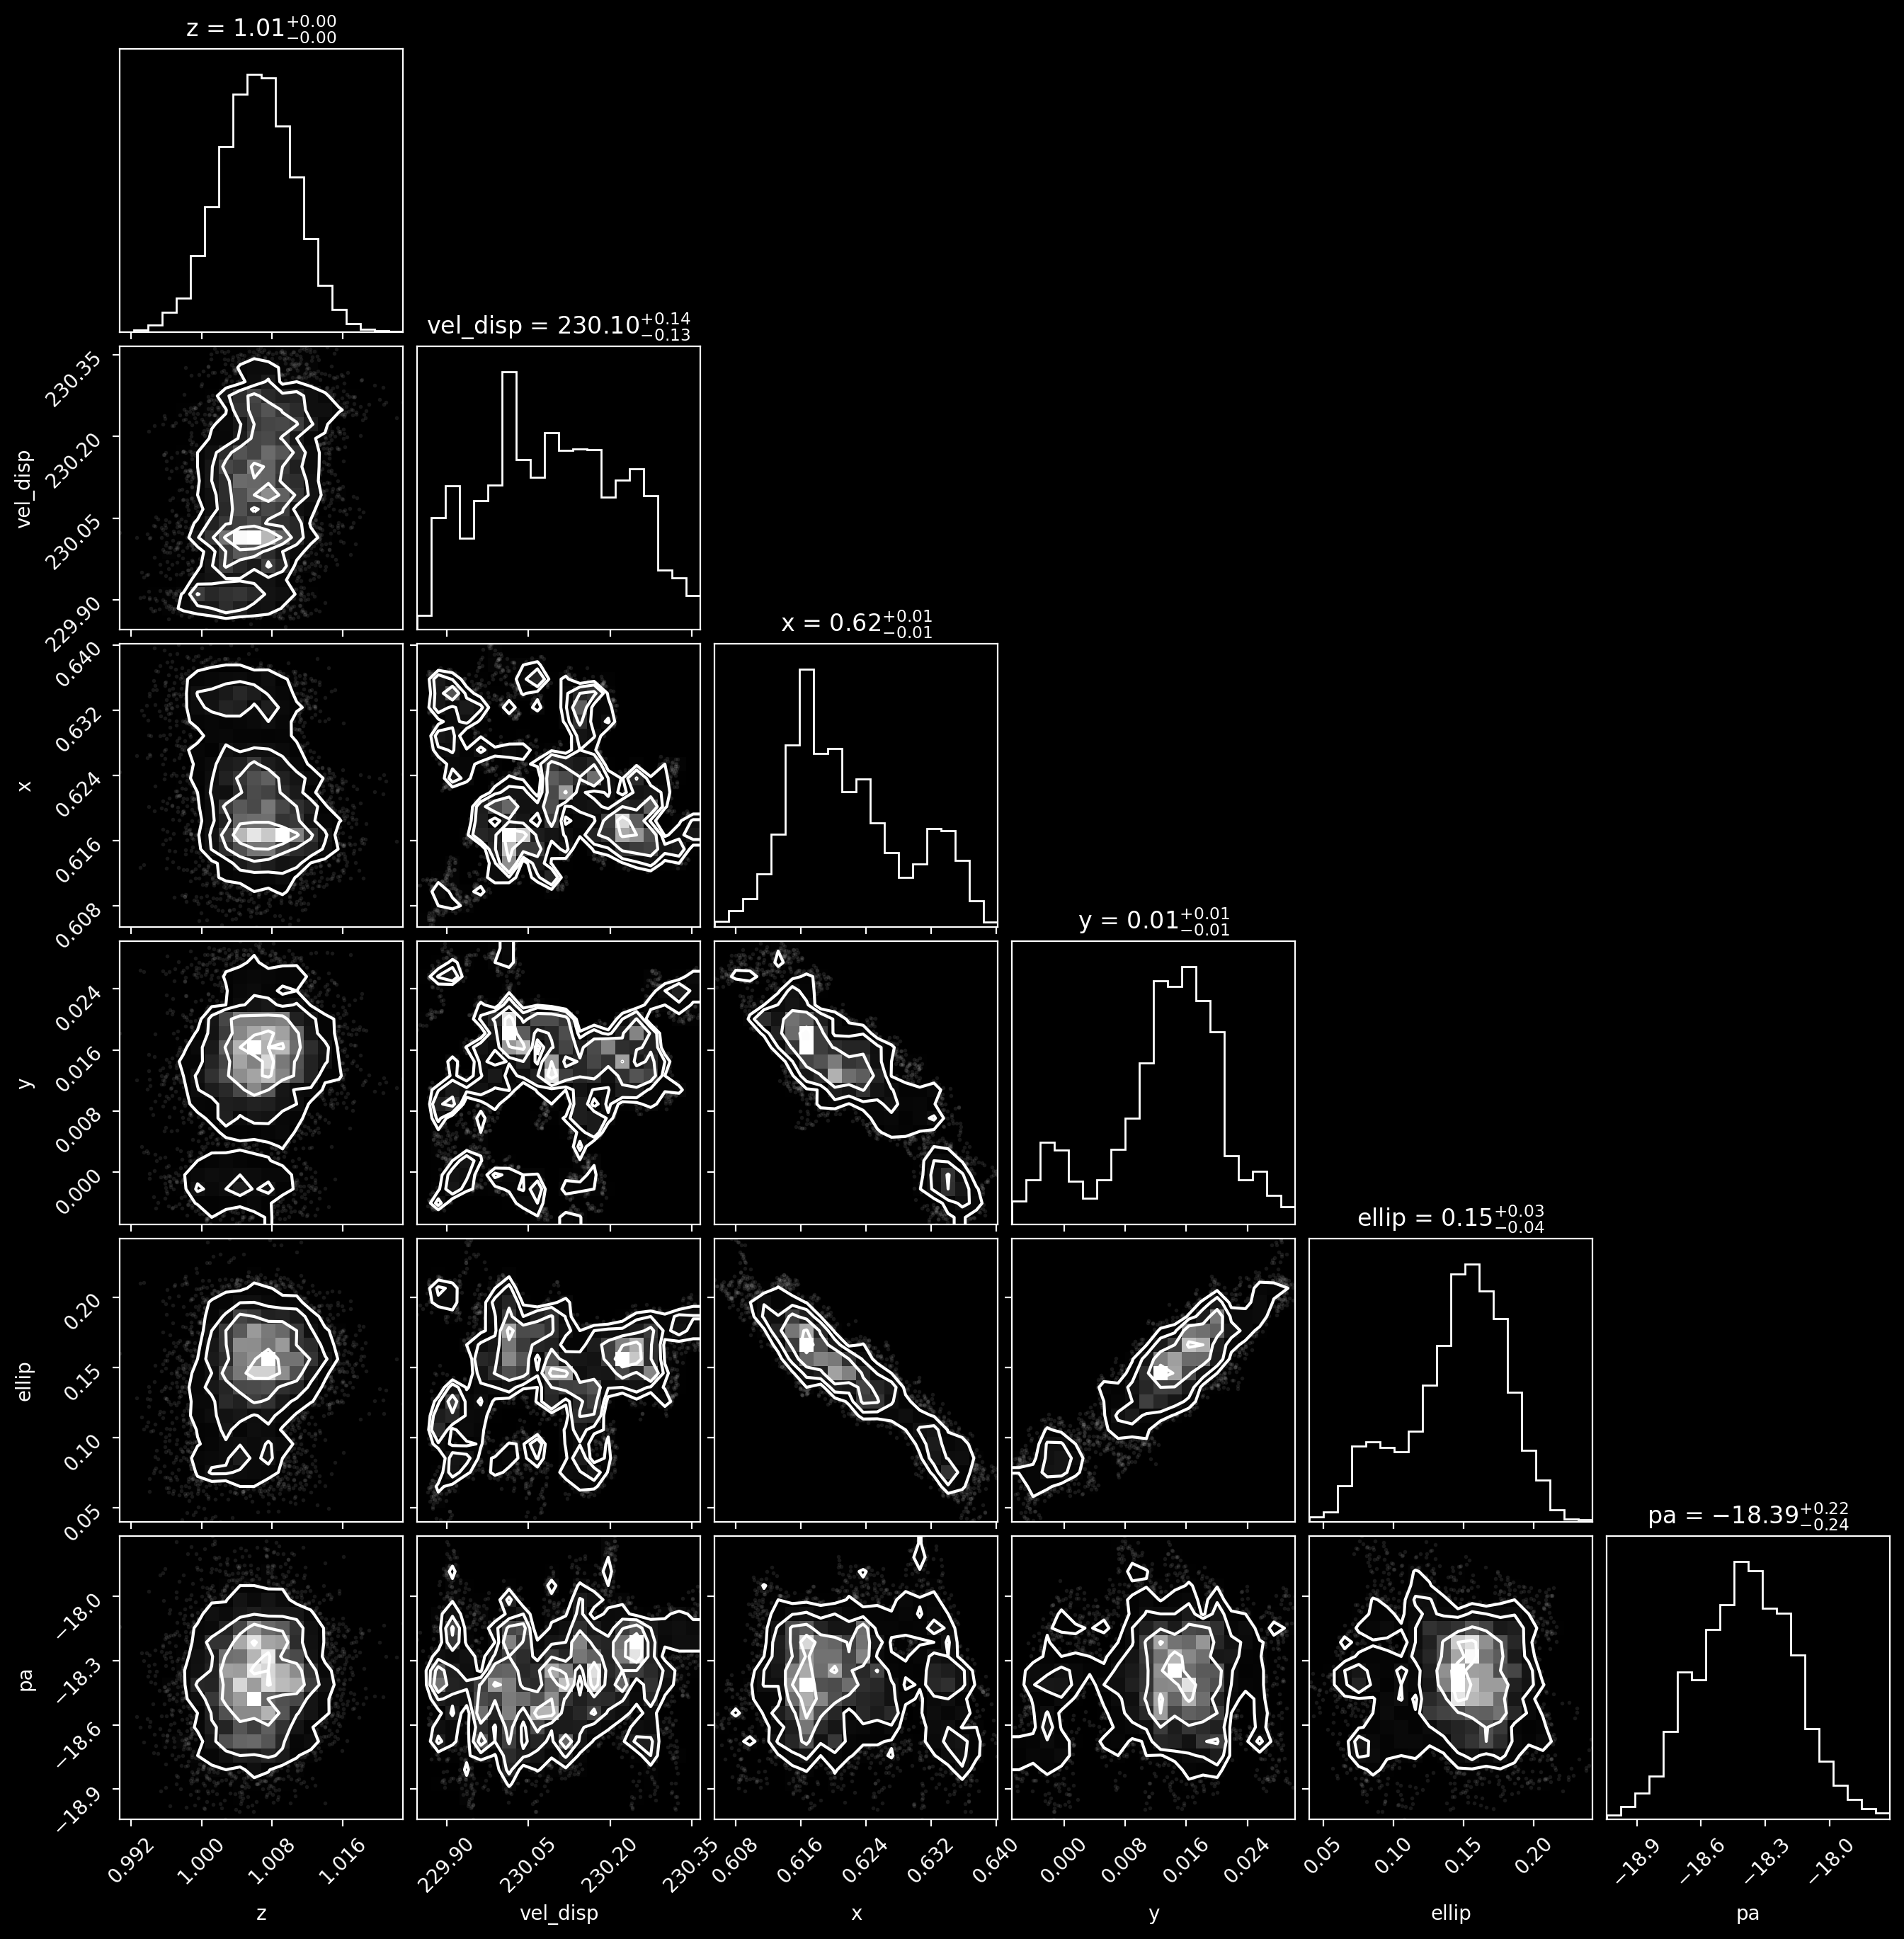

In [55]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')